In [7]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()

Rows and Columns: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
df = df.dropna(subset=['CustomerID'])

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

print(df.shape)

(397884, 8)


In [11]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


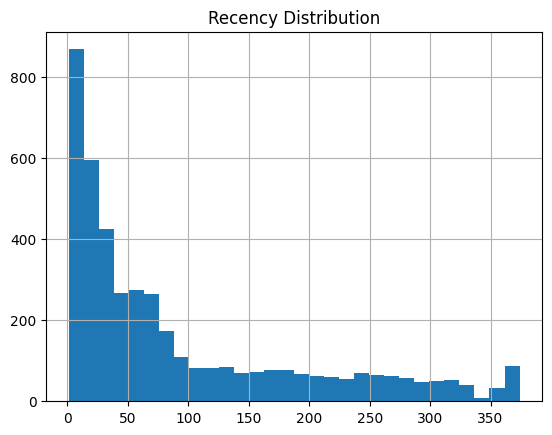

In [15]:
import matplotlib.pyplot as plt

rfm['Recency'].hist(bins=30)

plt.title("Recency Distribution")
plt.show()

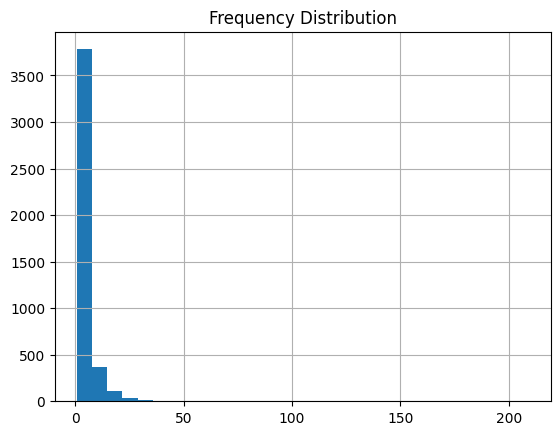

In [16]:
rfm['Frequency'].hist(bins=30)

plt.title("Frequency Distribution")
plt.show()

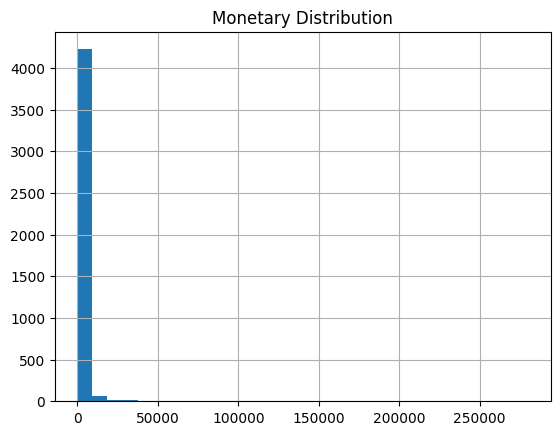

In [17]:
rfm['Monetary'].hist(bins=30)

plt.title("Monetary Distribution")
plt.show()

In [19]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [20]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [21]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [22]:
def segment_customer(score):

    score = int(score)

    if score >= 555:
        return "Champions"

    elif score >= 455:
        return "Loyal Customers"

    elif score >= 355:
        return "Potential Loyalists"

    elif score >= 255:
        return "Promising"

    elif score >= 155:
        return "Needs Attention"

    else:
        return "At Risk"

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,At Risk
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,Needs Attention
12349.0,19,1,1757.55,4,1,4,414,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,At Risk


In [23]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,860
Needs Attention,820
Promising,806
Potential Loyalists,806
Loyal Customers,698
Champions,348


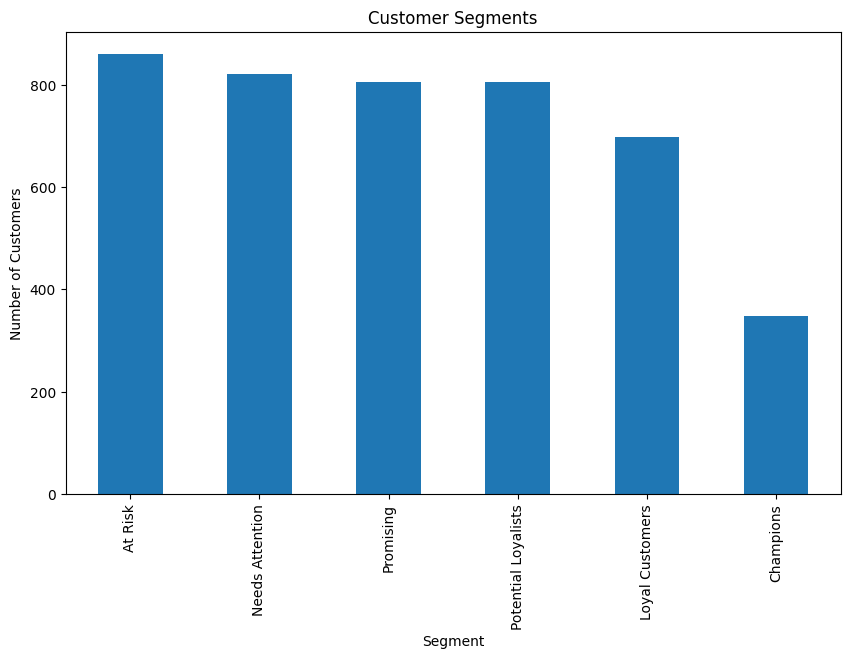

In [24]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))
segment_counts.plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

In [25]:
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

,Monetary
Segment,
Champions,11221.741121
Loyal Customers,2645.997579
Potential Loyalists,1439.109716
Promising,988.634144
Needs Attention,811.770039
At Risk,624.328722


In [26]:
rfm.to_csv('customer_segments.csv')

In [27]:
from google.colab import files

files.download('customer_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,860
Needs Attention,820
Promising,806
Potential Loyalists,806
Loyal Customers,698
Champions,348


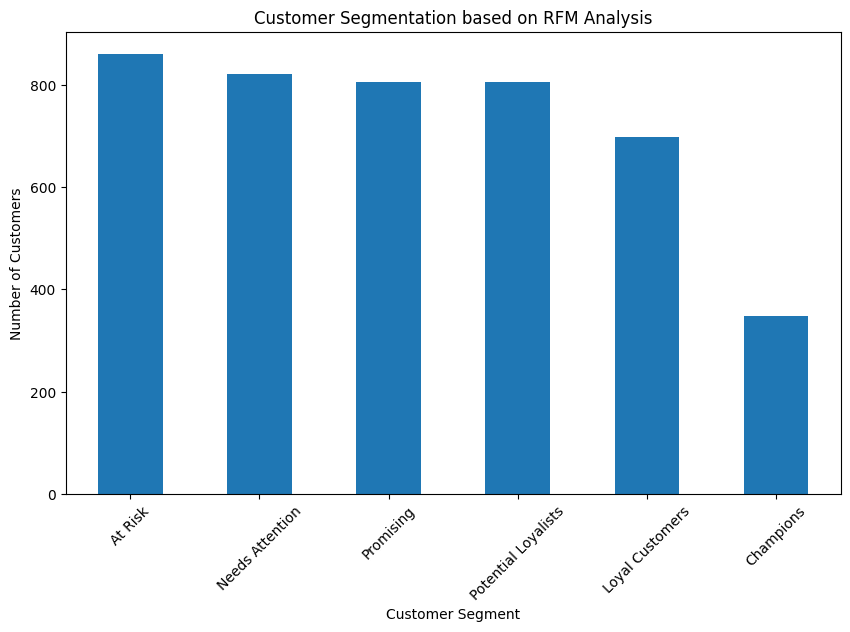

In [29]:
import matplotlib.pyplot as plt

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))
segment_counts.plot(kind='bar')

plt.title('Customer Segmentation based on RFM Analysis')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

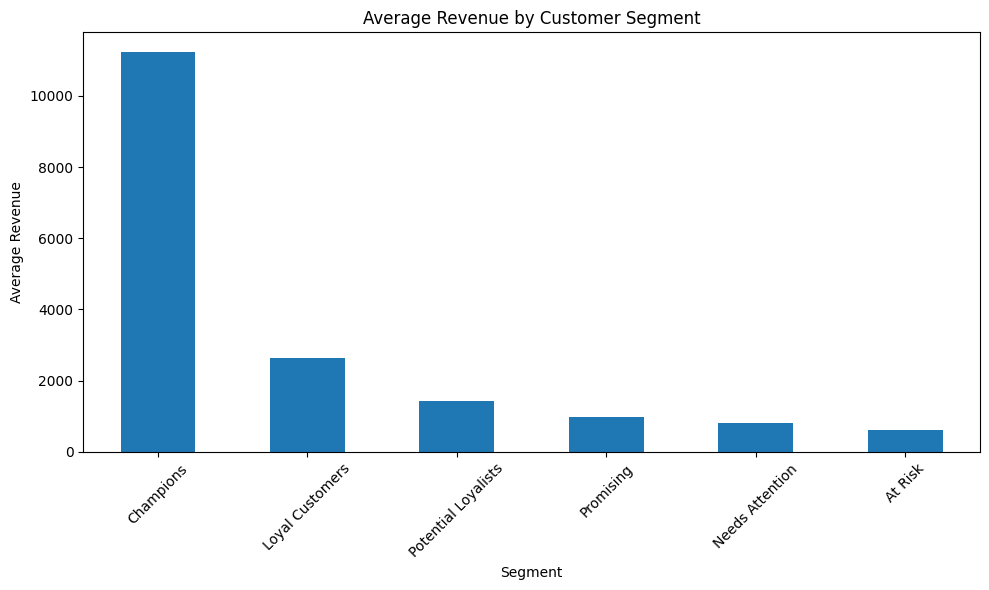

In [30]:
revenue_by_segment = (
    rfm.groupby('Segment')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
revenue_by_segment.plot(kind='bar')

plt.title('Average Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
rfm.to_csv("customer_segments.csv")

In [32]:
from google.colab import files
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>